# FDCA Part I — Walkthrough paso a paso

Este notebook desglosa **`part1.py`** del pipeline GERIS-PFC, ejecutando cada etapa de forma aislada y mostrando qué produce.

La estructura sigue las secciones ATBD 3.4.2.1 → 3.4.2.13:

| Sección | Qué hace |
|---------|----------|
| 3.4.2.1 | Albedo y brillo visible |
| 3.4.2.2 | Banda híbrida FPT + producto Reflectividad |
| 3.4.2.3 | Tests de nube y geometría |
| 3.4.2.4 | Test along-scan |
| 3.4.2.5 | Background estadístico |
| 3.4.2.6 | Umbrales contextuales |
| 3.4.2.7 | Identificación inicial de píxeles de fuego |
| 3.4.2.8 | Correcciones TPW + emisividad + solar |
| 3.4.2.9 | Tests post-corrección |
| 3.4.2.10 | Dozier sub-pixel + área |
| 3.4.2.11 | Last-chance fire test |
| 3.4.2.12 | FRP |
| 3.4.2.13 | Registro del candidato |



## 0. Setup: cargar repo del proyecto y archivos a utilizar


In [1]:
import os
import sys
import subprocess
from pathlib import Path

# Detectar si estamos en Google Colab
try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BRANCH = "testing-fdca-real"

if IN_COLAB:
    print("Ejecutando en Google Colab")

    GH_TOKEN = userdata.get("GITHUB_TOKEN")
    REPO_URL = f"https://{GH_TOKEN}@github.com/Vale23-23/GERIS-PFC.git"
    CLONE_DIR = "/content/GERIS-PFC"

    if not os.path.exists(CLONE_DIR):
        result = subprocess.run(
            [
                "git", "clone",
                "--branch", BRANCH,
                "--depth", "1",
                REPO_URL,
                CLONE_DIR
            ],
            capture_output=True,
            text=True
        )

        if result.returncode != 0:
            raise RuntimeError(result.stderr)

        print("Repo clonado OK")

    else:
        pull = subprocess.run(
            ["git", "-C", CLONE_DIR, "pull"],
            capture_output=True,
            text=True
        )
        print("Pull OK")

    PROJECT_ROOT = Path(CLONE_DIR) / "implementacion"

else:
    print("Ejecutando localmente (VS Code u otro IDE)")

    cwd = Path.cwd()
    if (cwd / "implementacion" / "fdca").exists():
        PROJECT_ROOT = cwd / "implementacion"
    elif (cwd / "fdca").exists():
        PROJECT_ROOT = cwd
    else:
        PROJECT_ROOT = cwd

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

sys.path.insert(0, str(PROJECT_ROOT))

Ejecutando localmente (VS Code u otro IDE)
PROJECT_ROOT = c:\Users\luciana\Desktop\Fing\PFC\GERIS-PFC\implementacion


In [3]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Celda 2: bajar datos desde Hugging Face ───────────────────────────────
import os

try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    HF_TOKEN = userdata.get("HF_TOKEN")
    DATA_ROOT = "/content/data"
else:
    from dotenv import load_dotenv

    env_candidates = [Path.cwd() / ".env", Path.cwd().parent / ".env"]
    for env_path in env_candidates:
        if env_path.exists():
            load_dotenv(env_path)
            break

    HF_TOKEN = os.getenv("HF_TOKEN")
    DATA_ROOT = Path.cwd() / "data"

from huggingface_hub import snapshot_download

HF_REPO_ID = "valentina2323/GERIS-Goes19-uruguay-fires"
TIMESTAMP = "20250926_1900"
LOCAL_DATA = os.path.join(DATA_ROOT, TIMESTAMP)

os.makedirs(LOCAL_DATA, exist_ok=True)

snapshot_download(
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    token=HF_TOKEN,
    allow_patterns=[
        f"uruguay/*/{TIMESTAMP}.npy",
        "uruguay/**/*.json",
    ],
    local_dir=str(DATA_ROOT),
)

print(f"Datos en: {LOCAL_DATA}")

c:\Users\luciana\miniconda3\envs\geris\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching ... files: 18it [00:00, 68.03it/s]

Datos en: c:\Users\luciana\Desktop\Fing\PFC\GERIS-PFC\implementacion\data\20250926_1900


In [4]:
from pathlib import Path

print(list(Path(DATA_ROOT).glob("*")))

[WindowsPath('c:/Users/luciana/Desktop/Fing/PFC/GERIS-PFC/implementacion/data/.cache'), WindowsPath('c:/Users/luciana/Desktop/Fing/PFC/GERIS-PFC/implementacion/data/20250926_1900'), WindowsPath('c:/Users/luciana/Desktop/Fing/PFC/GERIS-PFC/implementacion/data/uruguay')]


## 1. Cargar datos de entrada (`FDCAInput`)

Usamos la misma escena de prueba del README: timestamp `20250926_1900`.

In [3]:
# ── Celda 3: imports y carga del input ───────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import json, warnings

# Módulos del proyecto
from fdca.fdca_adapter import load_fdca_input
from fdca.constants import FireMask, FailChar, BKG_MAX_ITER
from fdca.planck import planck_rad, planck_temp
from fdca.background import compute_background
from fdca.dozier import compute_dozier, compute_frp, compute_pixel_area
from fdca.part1 import (
    FireCandidate, _contextual_thresholds,
    _tpw_lut_indices, _solar_correction,
    run_part1,
)
from fdca.constants import *

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [4]:
import sys
import numpy as np
sys.path.insert(0, str(PROJECT_ROOT))

from fdca.fdca_adapter import load_fdca_input

CONFIG_PATH = str(PROJECT_ROOT / "fdca" / "config.yaml")
DATASET_ROOT = str(DATA_ROOT)   # si la celda anterior definió DATA_ROOT

inp = load_fdca_input(
    timestamp=TIMESTAMP,
    region="uruguay",
    config_path=CONFIG_PATH,
    dataset_root=DATASET_ROOT,
    verbose=True
)

print(f"Grilla: {inp.bt7.shape}  |  BT7 [{np.nanmin(inp.bt7):.1f}, {np.nanmax(inp.bt7):.1f}] K")



  ABI-L1b-Rad-B07       : shape=(224, 303)  range=[375411.93, 16659234.14]
  ABI-L1b-Rad-B14       : shape=(224, 303)  range=[6050503.66, 15665017.56]
  ABI-L1b-Rad-B13       : shape=(224, 303)  range=[6271651.58, 16675723.47]
  ABI-L1b-Rad-B15       : shape=(224, 303)  range=[5008342.09, 12041746.38]
  ABI-L1b-Rad-B02       : shape=(893, 1212)  range=[12.06, 344.00]

  SZA range [°]         : 48.0 – 55.9
  LZA range [°]         : 31.3 – 40.1
  Píxeles diurnos       : 100%

  BT7 range [K]         : 288.9 – 410.9
  BT14 range [K]        : 271.9 – 339.2
  refl2 range           : 0.051 – 0.352
  TPW range [mm]        : 25.0 – 35.0  (estimación climatológica)

  ✓ FDCAInput construido — shape (224, 303)
Grilla: (224, 303)  |  BT7 [288.9, 410.9] K


In [5]:
import pandas as pd

# Ver los atributos principales del objeto
fields = {
    "campo": [],
    "tipo": [],
    "shape": [],
}

for name in dir(inp):
    if name.startswith("_"):
        continue
    value = getattr(inp, name)
    if hasattr(value, "shape"):
        fields["campo"].append(name)
        fields["tipo"].append(type(value).__name__)
        fields["shape"].append(value.shape)
    elif hasattr(value, "__len__") and not isinstance(value, (str, bytes)):
        try:
            fields["campo"].append(name)
            fields["tipo"].append(type(value).__name__)
            fields["shape"].append(len(value))
        except Exception:
            pass

pd.DataFrame(fields).head(50)

,campo,tipo,shape
0,azimuth,ndarray,"(224, 303)"
1,bt13,ndarray,"(224, 303)"
2,bt14,ndarray,"(224, 303)"
3,bt15,ndarray,"(224, 303)"
4,bt7,ndarray,"(224, 303)"
5,desert_mask,ndarray,"(224, 303)"
6,emiss14,ndarray,"(224, 303)"
7,emiss7,ndarray,"(224, 303)"
8,glint_angle,ndarray,"(224, 303)"
9,land_cover,ndarray,"(224, 303)"


In [9]:
# Ejemplo: ver un resumen de una variable
pd.Series(inp.sza[0, :10]).to_frame(name="BT7 primer fila")

,BT7 primer fila
0,48.010540
1,48.028419
2,48.046314
3,48.064198
4,48.082088
5,48.099991
6,48.117889
7,48.135788
8,48.153698
9,48.171619


---
## Paso 1 — ATBD 3.4.2.1: Albedo y brillo visible

El albedo normalizado por SZA se calcula como:
$$\text{albedo}_{ij} = \frac{\text{refl2}_{ij}}{\cos(\text{SZA}_{ij})}$$

Solo aplica de día (`SZA ≤ MAX_SZA_DAYLIGHT = 85°`).
Esto corrige la reflectancia cruda por el ángulo de iluminación solar: a mayor SZA, el sol ilumina más oblicuamente y la misma superficie parece más brillante en reflectancia cruda. Al dividir por cos(SZA) se obtiene una medida más "física" de la reflectividad real.

Se maneja en una escala adimensional que va de 0.0 a 1.5 (donde valores mayores a 1.0 surgen técnicamente por la geometría de la reflexión y el ruido).  


In [6]:
#from fdca.part1 import calculate_albedo


L, W    = inp.bt7.shape

#ponerlo en parte1

def calculate_albedo(L: int, W: int, sza: np.ndarray, refl2: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:

        # ── Daylight flag ─────────────────────────────────────────────────────────
        is_day = (sza >= 0.0) & (sza <= MAX_SZA_DAYLIGHT)
        
        sza_cos = np.cos(np.radians(sza))

        # ── Albedo and visible brightness (ATBD 3.4.2.1) ─────────────────────────
        albedo         = np.full((L, W), np.nan)
        vis_brightness = np.zeros ((L, W), dtype=np.float32)
        if refl2 is not None:
            with np.errstate(invalid="ignore", divide="ignore"):
                albedo = np.where(is_day, refl2 / np.where(sza_cos > 0, sza_cos, np.nan), np.nan)
            vis_brightness = (255.0 * np.sqrt(np.clip(refl2, 0, None))).astype(np.float32)

        return albedo, vis_brightness, is_day, sza_cos

albedo, vis_brightness, is_day, sza_cos = calculate_albedo(L, W, inp.sza, inp.refl2)


print(f'Píxeles diurnos : {is_day.sum():,} / {L*W:,} ({100*is_day.mean():.1f}%)')
print(f'Albedo válido   : {np.isfinite(albedo).sum():,} píxeles')
print(f'Albedo rango    : [{np.nanmin(albedo):.4f}, {np.nanmax(albedo):.4f}]')

Píxeles diurnos : 67,872 / 67,872 (100.0%)
Albedo válido   : 67,872 píxeles
Albedo rango    : [0.0878, 0.5563]


In [14]:
albedo.mean()

0.16789068

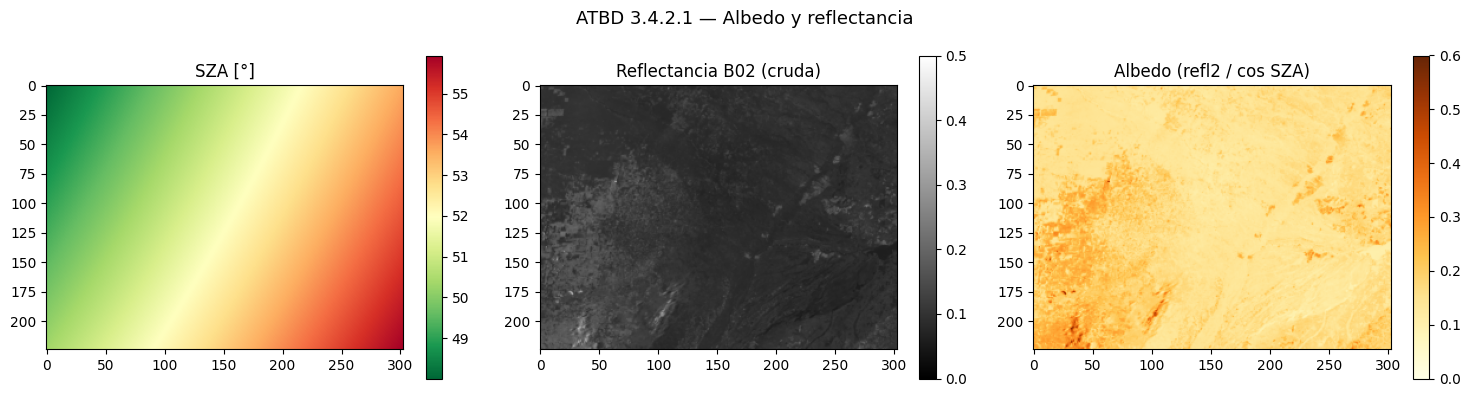

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(inp.sza, cmap='RdYlGn_r', origin='upper')
plt.colorbar(im0, ax=axes[0])
axes[0].set_title('SZA [°]')

if inp.refl2 is not None:
    im1 = axes[1].imshow(inp.refl2, cmap='gray', origin='upper', vmin=0, vmax=0.5)
    plt.colorbar(im1, ax=axes[1])
    axes[1].set_title('Reflectancia B02 (cruda)')
else:
    axes[1].text(0.5, 0.5, 'B02 no disponible', ha='center', va='center', transform=axes[1].transAxes)

im2 = axes[2].imshow(albedo, cmap='YlOrBr', origin='upper', vmin=0, vmax=0.6)
plt.colorbar(im2, ax=axes[2])
axes[2].set_title('Albedo (refl2 / cos SZA)')

plt.suptitle('ATBD 3.4.2.1 — Albedo y reflectancia', fontsize=13)
plt.tight_layout()
plt.show()

El sol está más alto en el cielo hacia la izquierda de la imagen (oeste) y más bajo (más inclinado, proyectando más sombras) hacia la derecha (este). Esta inclinación causa que, a igual tipo de suelo, la derecha de la imagen reciba naturalmente menos iluminación solar directa que la izquierda.
El albedo es el factor de reflectancia corregido y normalizado que utiliza el FDCA para sus árboles de decisión diurnos. Al dividir la reflectancia cruda por el coseno del ángulo solar (SZA) de cada píxel, eliminás el efecto de iluminación oblicua causado por la curvatura de la Tierra y la hora del día. Los valores dominantes están en el rango de 0.1 a 0.25 (tonos amarillos y crema suaves), que es el rango exacto de validación física para pastizales, campos de cultivo y montes limpios en el Cono Sur. Hacia el extremo inferior izquierdo (suroeste), se aprecian algunas estructuras con un albedo levemente más alto (tonos naranja/marrón de 0.25 a 0.35) que podrían ser suelos más descubiertos, texturas de biomas mixtos o nubes muy delgadas/humo que empiezan a dispersar luz visible sin llegar al umbral crítico de nube opaca (>0.38).  

---
## Paso 2 — ATBD 3.4.2.2: Banda híbrida FPT + producto Reflectividad

Si la temperatura del plano focal (`FPT > FPT_THRESHOLD`), el detector de B07 está tan caliente que contamina las mediciones, y en ese caso se substituye B14 por B13, donde reduce la diferencia con B07. Luego se calcula el **producto Reflectividad** para todos los píxeles:

$$\text{Refl}_{ij} = \text{rad7}_{ij} - B_{\text{Planck}}(7,\, \text{BT14}_{ij})$$

In [7]:
# Leer FPT del input 
FPT = inp.FPT
AFFECTED_PIXELS = FPT > FPT_THRESHOLD # Si FPT supera el umbral, entonces hay pixeles afectados

print(f'FPT= {FPT:.2f}   |   FPT_THRESHOLD = {FPT_THRESHOLD} K   |   posible uso híbrido = {AFFECTED_PIXELS}')

if AFFECTED_PIXELS == True :
    use_hybrid = False
else:
    use_hybrid = True #es como overkill, podriamos ver que sea con el 10% afectados

if use_hybrid and inp.bt13 is not None:
    rad13_in_ch7 = planck_rad(7, inp.bt13)
    rad14_in_ch7 = planck_rad(7, inp.bt14)
    refl_7_14 = inp.rad7 - rad14_in_ch7
    refl_7_13 = inp.rad7 - rad13_in_ch7

    use_ch13  = np.abs(refl_7_13) < np.abs(refl_7_14)
    bt14_eff  = np.where(use_ch13, inp.bt13, inp.bt14)
    rad14_eff = np.where(use_ch13, inp.rad13, inp.rad14)
    print(f'Píxeles donde B13 reemplaza B14: {use_ch13.sum():,}')
else:
    bt14_eff  = inp.bt14
    rad14_eff = inp.rad14
    print('Usando B14 estándar (sin banda híbrida)')

# Producto Reflectividad
rad14_in_7 = planck_rad(7, bt14_eff)
refl       = inp.rad7 - rad14_in_7
bad_rad    = (inp.rad7 < 0) | (rad14_eff < 0)
refl       = np.where(bad_rad, -9999.0, refl)

print(bad_rad.sum())
print(refl.min())


FPT= 0.00   |   FPT_THRESHOLD = 90.0 K   |   posible uso híbrido = False
Píxeles donde B13 reemplaza B14: 54,097
0
-12239.599896157684


Por qué printea que se usa B13 en 54097 pixeles???

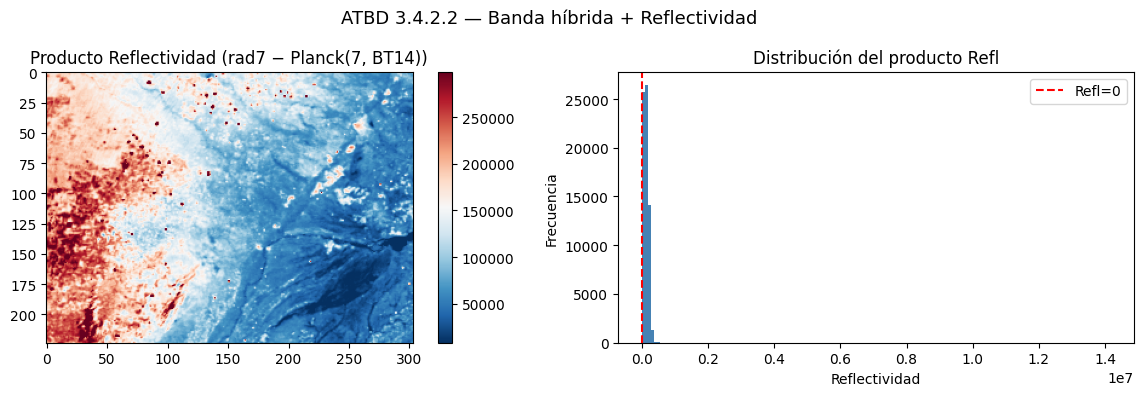

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

refl_plot = refl.copy()
im0 = axes[0].imshow(refl_plot, cmap='RdBu_r', origin='upper',
                     vmin=np.nanpercentile(refl_plot, 1),
                     vmax=np.nanpercentile(refl_plot, 99))
plt.colorbar(im0, ax=axes[0])
axes[0].set_title('Producto Reflectividad (rad7 − Planck(7, BT14))')

axes[1].hist(refl_plot[np.isfinite(refl_plot)].ravel(), bins=150, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Reflectividad')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del producto Refl')
axes[1].axvline(0, color='red', linestyle='--', label='Refl=0')
axes[1].legend()

plt.suptitle('ATBD 3.4.2.2 — Banda híbrida + Reflectividad', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 3 — ATBD 3.4.2.3: Tests de geometría y nube. PRIMER FILTRO GRUESO.

Aplicamos los filtros de **descarte rápido** sobre toda la grilla y asignamos un código en `fire_mask`. Mostramos cuántos píxeles quedan en cada categoría.

In [8]:
# ── ATBD 3.4.2.3 — Test data against thresholds──────────────────────────
fire_mask = np.full((L, W), FireMask.INIT, dtype=np.int32) # INIT o FIRE_FREE?
cloud_mask = np.zeros((L, W), dtype=bool)

# 1. Space (NaN en BT7) 
space = np.isnan(inp.bt7)
fire_mask[space] = FireMask.SPACE

remaining = fire_mask == FireMask.INIT

# 2. Local zenith angle
zenith_block = remaining & (inp.lza > MAX_LOCAL_ZENITH)
fire_mask[zenith_block] = FireMask.ZENITH_BLOCK

remaining = fire_mask == FireMask.INIT

# 3. Sun glint 
glint_block = remaining & ((inp.lza < GLINT_THRESHOLD) | (inp.glint_angle < GLINT_THRESHOLD)) #revisar si es sza o lza
fire_mask[glint_block] = FireMask.GLINT_BLOCK

is_day = (inp.sza >= 0.0) & (inp.sza <= MAX_SZA_DAYLIGHT)
# 3b. Canal 14 faltante (ATBD 3.4.2.3, código 121)
miss14 = remaining & np.isnan(bt14_eff)
fire_mask[miss14] = FireMask.MISS_CH14
remaining = fire_mask == FireMask.INIT

# 4. Saturation / unusable temperatures
sat7 = remaining & (inp.bt7 > SAT_TEMP_CH7 + SAT_BUFF)
fire_mask[sat7] = FireMask.SAT_CH7
remaining = fire_mask == FireMask.INIT

sat14 = remaining & (bt14_eff > SAT_TEMP_CH14 + SAT_BUFF)
fire_mask[sat14] = FireMask.SAT_CH14
remaining = fire_mask == FireMask.INIT

unus7 = remaining & (inp.bt7 < MIN_BT)
fire_mask[unus7] = FireMask.UNUS_CH7
remaining = fire_mask == FireMask.INIT

unus14 = remaining & (bt14_eff < MIN_BT)
fire_mask[unus14] = FireMask.UNUS_CH14
remaining = fire_mask == FireMask.INIT

# 5. Radiance quality
neg_rad = remaining & ((inp.rad7 < 0) | (rad14_eff < 0))
fire_mask[neg_rad] = FireMask.NEG_RAD
remaining = fire_mask == FireMask.INIT

# 6. Ecosystem masks
# Pixeles donde no se deberia buscar incendios porque son agua o desierto brillante
bad_eco = remaining & (np.isin(inp.land_cover, MODIS_WATER_CODES)| (inp.land_cover == UMD_WATER_CODE) | (inp.desert_mask == DESERT_BRIGHT))
fire_mask[bad_eco] = FireMask.BAD_ECOSYSTEM # Este filtro dice que se aplica a los vecinos tambien, faltaria ver eso
remaining = fire_mask == FireMask.INIT

sea = remaining & (inp.usgs_eco == USGS_SEA_WATER)
fire_mask[sea] = FireMask.SEA_WATER
remaining = fire_mask == FireMask.INIT

coast = remaining & np.isin(inp.usgs_eco, USGS_COAST_FRINGE)
fire_mask[coast] = FireMask.COAST_FRINGE
remaining = fire_mask == FireMask.INIT

inland = remaining & np.isin(inp.usgs_eco, USGS_INLAND_WATER)
fire_mask[inland] = FireMask.INLAND_WATER
remaining = fire_mask == FireMask.INIT

# 7. Minimum BT difference (ATBD: primero fire-free/100, después too-cold/201)
diff = inp.bt7 - bt14_eff
fire_free = (remaining & (np.abs(diff) <= CH_DIFF) & ((inp.bt7 > BRIGHTNESS_THRESHOLD) | (bt14_eff > BRIGHTNESS_THRESHOLD)))
fire_mask[fire_free] = FireMask.FIRE_FREE
remaining = fire_mask == FireMask.INIT

too_cold = (remaining & (np.abs(diff) < CH_DIFF) & ((inp.bt7 <= BRIGHTNESS_THRESHOLD) | (bt14_eff <= BRIGHTNESS_THRESHOLD)))
fire_mask[too_cold] = FireMask.TOO_COLD
remaining = fire_mask == FireMask.INIT

# 8. Dynamic thresholds que dependen de la hora del día
bt7_min = np.full(inp.bt7.shape, BT7_MIN_NIGHT)
bt7_refl_thr = np.full(inp.bt7.shape, BT7_REFL_THRESH_NIGHT)

cos_sza = np.cos(np.deg2rad(inp.sza))

bt7_min[is_day] = BT7_MIN_NIGHT + BT7_MIN_SOLAR_COEF * cos_sza[is_day]
bt7_refl_thr[is_day] = BT7_REFL_THRESH_NIGHT + BT7_REFL_THRESH_SOLAR * cos_sza[is_day]


# 9. Cloud tests
# los tests de nube NO sacan al píxel de carrera (ATBD 3.4.2.3)
cloud_bt14 = remaining & (bt14_eff < CLOUD_BT14_THRESH)
fire_mask[cloud_bt14] = FireMask.CLOUD_BT14
cloud_mask[cloud_bt14] = True

cloud_bt7_bt14_neg = remaining & ((inp.bt7 - bt14_eff) < CLOUD_BT7_BT14_NEG)
fire_mask[cloud_bt7_bt14_neg] = FireMask.CLOUD_BT14_BT15_NEG  
cloud_mask[cloud_bt7_bt14_neg] = True

cloud_bt7_bt14_pos = remaining & ((inp.bt7 - bt14_eff) > CLOUD_BT7_BT14_POS) & (inp.bt7 < CLOUD_BT7_FOR_POS)
fire_mask[cloud_bt7_bt14_pos] = FireMask.CLOUD_BT7_BT14_POS
cloud_mask[cloud_bt7_bt14_pos] = True

cloud_albedo = np.zeros((L, W), dtype=bool)
if inp.refl2 is not None:
    geom = ((inp.sza <= 70) | ((inp.sza <= 60) & (inp.lza <= 60)))
    cloud_albedo = remaining & is_day & geom & np.isfinite(albedo) & (albedo > CLOUD_ALBEDO_THRESH)
    fire_mask[cloud_albedo] = FireMask.CLOUD_ALBEDO
    cloud_mask[cloud_albedo] = True

cloud_bt15        = np.zeros((L, W), dtype=bool)
cloud_bt1415_neg  = np.zeros((L, W), dtype=bool)
cloud_bt1415_pos  = np.zeros((L, W), dtype=bool)
if inp.bt15 is not None:
    cloud_bt15 = remaining & (inp.bt15 <= CLOUD_BT15_THRESH)
    fire_mask[cloud_bt15] = FireMask.CLOUD_BT15
    cloud_mask[cloud_bt15] = True

    diff15 = bt14_eff - inp.bt15
    scope15 = remaining & (bt14_eff < CLOUD_BT14_THRESH)

    cloud_bt1415_neg = scope15 & (diff15 < CLOUD_BT14_BT15_NEG)
    fire_mask[cloud_bt1415_neg] = FireMask.CLOUD_BT14_BT15_NEG
    cloud_mask[cloud_bt1415_neg] = True

    cloud_bt1415_pos = scope15 & (diff15 > CLOUD_BT14_BT15_POS)
    fire_mask[cloud_bt1415_pos] = FireMask.CLOUD_BT14_BT15_POS
    cloud_mask[cloud_bt1415_pos] = True

# 'remaining' NO se reduce por los tests de nube: los pixeles nublados siguen
# en carrera para 3.4.2.4 y las etapas siguientes ("cloudy pixels MAY be
# found to contain fires later", ATBD 3.4.2.3)
categories = {
    'SPACE'                    : int(space.sum()),
    'ZENITH_BLOCK'             : int(zenith_block.sum()),
    'GLINT_BLOCK (bruto)*'     : int(glint_block.sum()),
    'MISS_CH14'                : int(miss14.sum()),
    'SAT_CH7'                  : int(sat7.sum()),
    'SAT_CH14'                 : int(sat14.sum()),
    'UNUS_CH7'                 : int(unus7.sum()),
    'UNUS_CH14'                : int(unus14.sum()),
    'BAD_ECOSYSTEM'            : int(bad_eco.sum()),
    'SEA_WATER'                : int(sea.sum()),
    'COAST_FRINGE'             : int(coast.sum()),
    'INLAND_WATER'             : int(inland.sum()),
    'NEG_RAD'                  : int(neg_rad.sum()),
    'FIRE_FREE'                : int(fire_free.sum()),
    'TOO_COLD'                 : int(too_cold.sum()),
    'CLOUD (union, algun test)': int(cloud_mask.sum()),
    '  · CLOUD_BT14'           : int(cloud_bt14.sum()),
    '  · CLOUD_BT7-BT14 neg'   : int(cloud_bt7_bt14_neg.sum()),
    '  · CLOUD_BT7-BT14 pos'   : int(cloud_bt7_bt14_pos.sum()),
    '  · CLOUD_ALBEDO'         : int(cloud_albedo.sum()),
    '  · CLOUD_BT15'           : int(cloud_bt15.sum()),
    '  · CLOUD_BT14-BT15 neg'  : int(cloud_bt1415_neg.sum()),
    '  · CLOUD_BT14-BT15 pos'  : int(cloud_bt1415_pos.sum()),
    'Candidatos restantes ("remaining")': int(remaining.sum()),
}

df_geo = pd.DataFrame(categories.items(), columns=['Estado', 'N pixeles'])
df_geo['% total'] = (df_geo['N pixeles'] / (L * W) * 100).round(2)
print(df_geo.to_string(index=False))


                            Estado  N pixeles  % total
                             SPACE          0     0.00
                      ZENITH_BLOCK          0     0.00
              GLINT_BLOCK (bruto)*          0     0.00
                         MISS_CH14          0     0.00
                           SAT_CH7          0     0.00
                          SAT_CH14          0     0.00
                          UNUS_CH7          0     0.00
                         UNUS_CH14          0     0.00
                     BAD_ECOSYSTEM          0     0.00
                         SEA_WATER          0     0.00
                      COAST_FRINGE          0     0.00
                      INLAND_WATER          0     0.00
                           NEG_RAD          0     0.00
                         FIRE_FREE      10560    15.56
                          TOO_COLD          0     0.00
         CLOUD (union, algun test)         94     0.14
                      · CLOUD_BT14          0     0.00
          

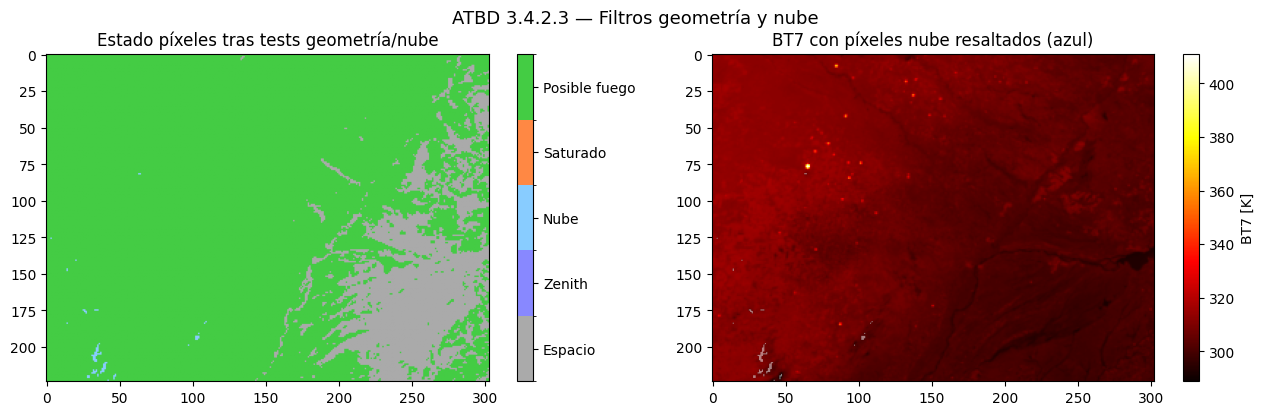

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Máscara de estado simplificada para visualizar
status_map = np.zeros((L, W), dtype=float)
status_map[space]         = 0
status_map[zenith_block]  = 1
status_map[cloud_mask]    = 2
status_map[sat7 | sat14] = 3
status_map[fire_mask == FireMask.INIT] = 4   # sin clasificar → candidato potencial

cmap = mcolors.ListedColormap(['#aaaaaa', '#8888ff', '#88ccff', '#ff8844', '#44cc44'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

im = axes[0].imshow(status_map, cmap=cmap, norm=norm, origin='upper')
cbar = plt.colorbar(im, ax=axes[0], ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(['Espacio', 'Zenith', 'Nube', 'Saturado', 'Posible fuego'])
axes[0].set_title('Estado píxeles tras tests geometría/nube')

# BT7 con máscara de nube superpuesta
im1 = axes[1].imshow(inp.bt7, cmap='hot', origin='upper')
plt.colorbar(im1, ax=axes[1], label='BT7 [K]')
cloud_overlay = np.ma.masked_where(~cloud_mask, cloud_mask)
axes[1].imshow(cloud_overlay, cmap='Blues', alpha=0.5, origin='upper')
axes[1].set_title('BT7 con píxeles nube resaltados (azul)')

plt.suptitle('ATBD 3.4.2.3 — Filtros geometría y nube', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 3.5 — ATBD 3.4.2.4: Test along-scan de reflectividad + flag de saturación

Antes de calcular el background, el algoritmo aplica un **test de reflectividad along-scan**: compara el producto `Refl` del píxel actual con el de los píxeles ubicados 3 posiciones a la izquierda (`Refl-3`) y 3 a la derecha (`Refl+3`) en la misma línea de escaneo, para detectar bordes de nube cercanos.

- **Nocturno** (o diurno sin albedo válido): si `BT7 < BT7_min` y `BT7 ≥ MIN_BT`, y (`Refl-3 < 0.2` o `Refl+3 < 0.2`) → `FireMask.ALONG_SCAN_NIGHT` (código 240), el píxel se descarta.
- **Diurno** (con albedo válido): si `Albedo ≥ 0.38` y `BT7 < 320 K`, y (`Refl-3 < 0.2` o `Refl+3 < 0.2`) → `FireMask.ALONG_SCAN_DAY` (código 245), el píxel se descarta.

**Importante:** este test corre sobre los píxeles que pasaron los filtros rápidos, *incluyendo los marcados como nube* en §3.4.2.3 — el ATBD dice explícitamente que esos píxeles "pueden ser encontrados como fuego más adelante", así que todavía no se descartan. Por eso en la celda del Paso 3 restauramos `remaining_before_clouds` (fix aplicado arriba) en vez de seguir angostando `remaining` con cada test de nube.

Inmediatamente después (todavía dentro del texto de la sección 3.4.2.4 del ATBD, antes de pasar a 3.4.2.5) se evalúa el **flag de saturación**: si `BT7 ≥ SAT_FLAG_CH7` (411.76 K) o `BT14 ≥ SAT_FLAG_CH14` (339.90 K) se marca `sat_flag=True` y se asigna `FailChar = 7` (Tabla 3.5). A diferencia del test `SAT_CH7`/`SAT_CH14` de la sección 3.4.2.3 (que usa un buffer de 5 K y **descarta** el píxel con `continue`), este umbral es más ajustado (saturación real − 0.1 K) y **no descarta** el píxel — sólo lo marca para saltarse más adelante la caracterización sub-píxel (Dozier).


In [10]:
# ── ATBD 3.4.2.4: test along-scan de reflectividad ─────────────────────────


# Vecinos a 3 posiciones en la misma fila (scan), con clamp de borde (no wrap-around) para no unir erroneamente este con oeste
idx        = np.arange(W)
idx_left   = np.clip(idx - 3, 0, W - 1)
idx_right  = np.clip(idx + 3, 0, W - 1)
refl_left  = refl[:, idx_left]
refl_right = refl[:, idx_right]

# Rama diurna vs. nocturna: mutuamente excluyentes
# En la documentacion no se aclara qué se hace si es de día pero refl no está disponible
night_test = remaining & ~is_day & (inp.bt7 < bt7_min) & (inp.bt7 >= MIN_BT)
day_test   = remaining &  is_day & np.isfinite(albedo) & (albedo >= CLOUD_ALBEDO_THRESH) & (inp.bt7 < 320.0)

vecino_sospechoso = (refl_left < 0.2) | (refl_right < 0.2)

along_scan_night = night_test & vecino_sospechoso
fire_mask[along_scan_night] = FireMask.ALONG_SCAN_NIGHT

along_scan_day = day_test & vecino_sospechoso
fire_mask[along_scan_day] = FireMask.ALONG_SCAN_DAY

# Estos códigos sí sacan al píxel de carrera (ATBD: "proceeds to the next pixel")
remaining =  fire_mask == FireMask.INIT

# ── Flag de saturacion + FailChar = 7 (todavia ATBD 3.4.2.4) ───────────────
fail_char = np.full((L, W), FailChar.NONE, dtype=np.int32)

sat_flag = remaining & ((inp.bt7 >= SAT_FLAG_CH7) | (bt14_eff >= SAT_FLAG_CH14))
fail_char[sat_flag] = FailChar.F7

# ── Resumen ────────────────────────────────────────────────────────────────
categories_342_4 = {
    'Elegibles (día)'                      : int(day_test.sum()),
    'Elegibles (noche)'                    : int(night_test.sum()),
    'ALONG_SCAN_DAY (código 245)'          : int(along_scan_day.sum()),
    'ALONG_SCAN_NIGHT (código 240)'        : int(along_scan_night.sum()),
    'Candidatos restantes tras 3.4.2.4'    : int(remaining.sum()),
}
df_scan = pd.DataFrame(categories_342_4.items(), columns=['Estado', 'N píxeles'])
df_scan['% total'] = (df_scan['N píxeles'] / (L * W) * 100).round(2)
print(df_scan.to_string(index=False))

                           Estado  N píxeles  % total
                  Elegibles (día)         94     0.14
                Elegibles (noche)          0     0.00
      ALONG_SCAN_DAY (código 245)          0     0.00
    ALONG_SCAN_NIGHT (código 240)          0     0.00
Candidatos restantes tras 3.4.2.4      57218    84.30


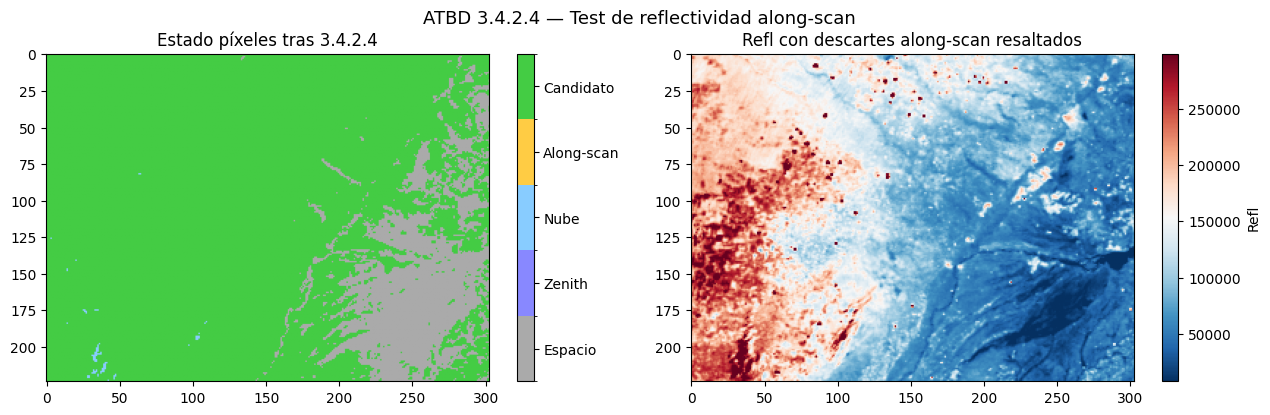

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Estado del píxel tras 3.4.2.4
status_map2 = np.zeros((L, W), dtype=float)
status_map2[space]                            = 0
status_map2[zenith_block]                     = 1
status_map2[cloud_mask]                       = 2
status_map2[along_scan_day | along_scan_night] = 3
status_map2[remaining]                        = 4

cmap2 = mcolors.ListedColormap(['#aaaaaa', '#8888ff', '#88ccff', '#ffcc44', '#44cc44'])
bounds2 = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm2   = mcolors.BoundaryNorm(bounds2, cmap2.N)

im = axes[0].imshow(status_map2, cmap=cmap2, norm=norm2, origin='upper')
cbar = plt.colorbar(im, ax=axes[0], ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(['Espacio', 'Zenith', 'Nube', 'Along-scan', 'Candidato'])
axes[0].set_title('Estado píxeles tras 3.4.2.4')

# Refl con los descartes resaltados, para ver que caen cerca de bordes de nube
im1 = axes[1].imshow(refl, cmap='RdBu_r', origin='upper',
                      vmin=np.nanpercentile(refl[np.isfinite(refl)], 1),
                      vmax=np.nanpercentile(refl[np.isfinite(refl)], 99))
plt.colorbar(im1, ax=axes[1], label='Refl')
scan_overlay = np.ma.masked_where(~(along_scan_day | along_scan_night), along_scan_day | along_scan_night)
axes[1].imshow(scan_overlay, cmap='Wistia', alpha=0.8, origin='upper')
axes[1].set_title('Refl con descartes along-scan resaltados')

plt.suptitle('ATBD 3.4.2.4 — Test de reflectividad along-scan', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 4a — ATBD 3.4.2.5 (detallado): Background condition statistics

Para un píxel candidato de ejemplo, el algoritmo calcula estadísticas de fondo en una
**ventana dinámica** centrada en el píxel:

- Empieza en `half=5` (ventana 11×11) y se agranda de a `+5` en cada dirección por
  iteración, hasta un máximo de 10 iteraciones (ventana final 111×111).
- Un píxel de la ventana es **válido** si:
  - es tierra (`land_mask`),
  - **no** es anómalamente cálido: `BT7 > 310K` (`+25·cos(SZA)` de día),
  - **no** es frío: `BT7 < 270K` o `BT14 < 270K`,
  - y **no** es "reflectivo/nube": `vis < 1` (8-bit) o `Albedo ≥ 0.38`.
- Los píxeles fuera de imagen (borde) **cuentan en el denominador** de la ventana pero
  nunca son válidos (así, cerca del borde, converge más lento).
- Se agranda la ventana hasta que **>= 20%** de las posiciones de la ventana son válidas.
  Si se llega a 10 iteraciones sin lograrlo: `FireMask.NO_BACKGROUND` (código 170) y se
  pasa al siguiente píxel.
- Una vez satisfecho el 20%, se calculan dos enfoques para la media/std de BT7 y BT14:
  - **Estadístico**: media/std directas sobre los valores válidos.
  - **Histograma**: se arma un histograma de enteros de BT7−BT14, se toma el bin con
    mayor frecuencia ± 1 vecino, y se calcula media/std sobre ese subconjunto.
  - Se usa el enfoque con **menor std de BT7** para definir `Temp7_Bkg_Mean`,
    `Temp14_Bkg_Mean` y `Vis_Mean_Bkg` (Tabla 3.6).

**Nota:** el ATBD menciona un "offset = min(5, n_passes/3)" para ajustar por tamaño de
ventana, pero ese ajuste **no se aplica acá** — se aplica más adelante, en
`_contextual_thresholds` (§3.4.2.6), usando el `n_passes` que devuelve este paso.

In [15]:
# ── ATBD 3.4.2.5 — elegimos un pixel de ejemplo ────────────────
np.random.seed(7)
candidatos_342_5 = np.argwhere(remaining)
i0, j0 = candidatos_342_5[np.random.randint(len(candidatos_342_5))]
i0, j0 = int(i0), int(j0)

print(f'Pixel de ejemplo: (i={i0}, j={j0})  |  BT7={inp.bt7[i0,j0]:.1f}K  BT14={bt14_eff[i0,j0]:.1f}K  '
      f'is_day={bool(is_day[i0,j0])}')

def _valid_bkg_mask(i_c, j_c, half):
    """
    Replica _valid_background_mask() de background.py sobre la ventana (i_c, j_c, half).
    Devuelve: mascara valida (recortada a los limites de la imagen), y window_size
    (que SI incluye fuera-de-imagen en el denominador, por ATBD).
    """
    i_min, i_max = i_c - half, i_c + half
    j_min, j_max = j_c - half, j_c + half
    window_size = (2 * half + 1) ** 2                 # incluye fuera-de-imagen

    i_lo, i_hi = max(0, i_min), min(L - 1, i_max)
    j_lo, j_hi = max(0, j_min), min(W - 1, j_max)

    bt7_win  = inp.bt7   [i_lo:i_hi+1, j_lo:j_hi+1]
    bt14_win = bt14_eff  [i_lo:i_hi+1, j_lo:j_hi+1]
    vis_win  = vis_brightness[i_lo:i_hi+1, j_lo:j_hi+1]
    alb_win  = albedo    [i_lo:i_hi+1, j_lo:j_hi+1]
    land_win = inp.land_mask[i_lo:i_hi+1, j_lo:j_hi+1]
    sc_win   = sza_cos   [i_lo:i_hi+1, j_lo:j_hi+1]
    day_win  = is_day    [i_lo:i_hi+1, j_lo:j_hi+1]

    warm_thr = BKG_WARM_BT7_NIGHT + np.where(day_win, BKG_WARM_SOLAR_COEF * sc_win, 0.0)
    warm = bt7_win > warm_thr
    cold = (bt7_win < BKG_COLD_THRESH) | (bt14_win < BKG_COLD_THRESH)
    # "reflective pixel threshold": vis < 1 (sin dato/oscuro) O albedo >= 0.38 (nube) -> excluido
    reflective = (vis_win < BKG_MIN_VIS) | (np.nan_to_num(alb_win, nan=0.0) >= BKG_MAX_ALBEDO)

    valid = land_win & ~warm & ~cold & ~reflective
    return valid, window_size, (i_lo, i_hi, j_lo, j_hi)

Pixel de ejemplo: (i=191, j=165)  |  BT7=300.9K  BT14=297.4K  is_day=True


In [16]:
# ── Expansión iterativa de la ventana hasta 20% valida (o max 10 iteraciones) ──
half   = BKG_WINDOW_INIT
n_iter = 0
rows_342_5 = []

while n_iter <= BKG_MAX_ITER:
    valid, window_size, bounds = _valid_bkg_mask(i0, j0, half)
    n_valid = int(valid.sum())
    frac    = n_valid / window_size
    cumple  = frac >= BKG_VALID_FRAC

    rows_342_5.append({
        'n_iter': n_iter,
        'half': half,
        'ventana': f'{2*half+1}x{2*half+1}',
        'window_size (con bordes)': window_size,
        'n_valid': n_valid,
        '% valido': round(frac * 100, 2),
        'cumple >=20%?': cumple,
    })

    if cumple:
        break

    n_iter += 1
    half   += BKG_WINDOW_STEP
else:
    valid = None  # no convergio -> FireMask.NO_BACKGROUND (codigo 170)

df_342_5 = pd.DataFrame(rows_342_5)
print(df_342_5.to_string(index=False))

if valid is None:
    print('\n⚠ No convergio en 10 iteraciones -> FireMask.NO_BACKGROUND (170)')
else:
    print(f'\nConvergio en n_iter={n_iter}, half={half} (ventana {2*half+1}x{2*half+1})')

 n_iter  half ventana  window_size (con bordes)  n_valid  % valido  cumple >=20%?
      0     5   11x11                       121      121     100.0           True

Convergio en n_iter=0, half=5 (ventana 11x11)


In [17]:
# ── Enfoque estadistico vs. histograma (solo si convergio) ─────────────────
if valid is not None:
    i_lo, i_hi, j_lo, j_hi = bounds
    bt7_vals  = inp.bt7 [i_lo:i_hi+1, j_lo:j_hi+1][valid]
    bt14_vals = bt14_eff[i_lo:i_hi+1, j_lo:j_hi+1][valid]
    vis_vals  = vis_brightness[i_lo:i_hi+1, j_lo:j_hi+1][valid]
    refl_vals = refl[i_lo:i_hi+1, j_lo:j_hi+1][valid]

    # Enfoque estadistico
    t7_stat_mean, t7_stat_std   = float(np.mean(bt7_vals)),  float(np.std(bt7_vals))
    t14_stat_mean, t14_stat_std = float(np.mean(bt14_vals)), float(np.std(bt14_vals))

    # Enfoque histograma: bin pico (redondeando a entero) +/- 1 vecino
    def _hist_mean_std(values):
        rounded = np.round(values).astype(int)
        bins = np.bincount(rounded - rounded.min())
        peak = rounded.min() + np.argmax(bins)
        sel  = values[(rounded >= peak - 1) & (rounded <= peak + 1)]
        return float(np.mean(sel)), float(np.std(sel)), int(peak)

    t7_hist_mean,  t7_hist_std,  t7_peak  = _hist_mean_std(bt7_vals)
    t14_hist_mean, t14_hist_std, t14_peak = _hist_mean_std(bt14_vals)
    vis_hist_mean, vis_hist_std, vis_peak = _hist_mean_std(vis_vals)

    # Se elige el enfoque con MENOR std de BT7 (ATBD 3.4.2.5, ultimo parrafo)
    usar_hist = t7_hist_std < t7_stat_std
    metodo = 'histograma' if usar_hist else 'estadistico'

    temp7_bkg_mean  = t7_hist_mean  if usar_hist else t7_stat_mean
    temp14_bkg_mean = t14_hist_mean if usar_hist else t14_stat_mean
    vis_mean_bkg    = vis_hist_mean if usar_hist else float(vis_peak)  # stat -> Histogram_Bin_Largest_Count

    print(f'BT7  -> stat: mean={t7_stat_mean:.2f}K std={t7_stat_std:.3f}  |  '
          f'hist: mean={t7_hist_mean:.2f}K std={t7_hist_std:.3f} (peak={t7_peak})')
    print(f'BT14 -> stat: mean={t14_stat_mean:.2f}K std={t14_stat_std:.3f}  |  '
          f'hist: mean={t14_hist_mean:.2f}K std={t14_hist_std:.3f} (peak={t14_peak})')
    print(f'\nMetodo elegido (menor std BT7): {metodo}')
    print(f'  Temp7_Bkg_Mean  = {temp7_bkg_mean:.2f} K')
    print(f'  Temp14_Bkg_Mean = {temp14_bkg_mean:.2f} K')
    print(f'  Vis_Mean_Bkg    = {vis_mean_bkg:.2f}')

    # Estadisticas de ventana completa SIN filtrar (usadas en 3.4.2.6: Reflb, Rad_Diff_Sigma)
    refl_full = refl[i_lo:i_hi+1, j_lo:j_hi+1].ravel()
    reflb          = float(np.mean(refl_full))
    rad_diff_sigma = float(np.std(refl_full))
    print(f'\nReflb (Rad_4mu_11mu_Avg_Diff, ventana completa) = {reflb:.4f}')
    print(f'Rad_Diff_Sigma (std, ventana completa)          = {rad_diff_sigma:.4f}')
    print(f'\nNumber_Passes_In_Bkg_Statistics = {n_iter}  (se usa en 3.4.2.6 para el offset min(5, n_passes/3))')

BT7  -> stat: mean=299.98K std=1.350  |  hist: mean=300.67K std=0.678 (peak=301)
BT14 -> stat: mean=297.27K std=0.907  |  hist: mean=297.70K std=0.432 (peak=298)

Metodo elegido (menor std BT7): histograma
  Temp7_Bkg_Mean  = 300.67 K
  Temp14_Bkg_Mean = 297.70 K
  Vis_Mean_Bkg    = 74.10

Reflb (Rad_4mu_11mu_Avg_Diff, ventana completa) = 64284.7008
Rad_Diff_Sigma (std, ventana completa)          = 15120.3110

Number_Passes_In_Bkg_Statistics = 0  (se usa en 3.4.2.6 para el offset min(5, n_passes/3))


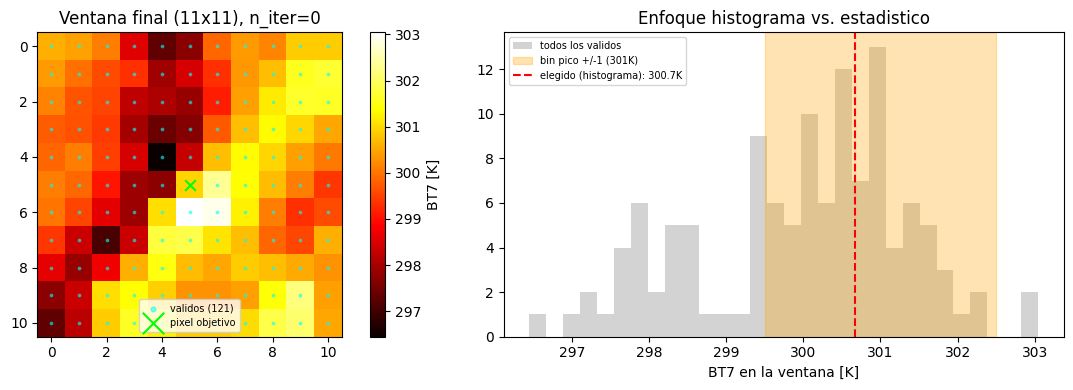

In [18]:
if valid is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Recorte BT7 con la ventana final marcada
    ax = axes[0]
    im = ax.imshow(inp.bt7[i_lo:i_hi+1, j_lo:j_hi+1], cmap='hot', origin='upper')
    plt.colorbar(im, ax=ax, label='BT7 [K]')
    vi, vj = np.where(valid)
    ax.scatter(vj, vi, s=3, c='cyan', alpha=0.5, label=f'validos ({valid.sum()})')
    ax.scatter([j0 - j_lo], [i0 - i_lo], s=60, c='lime', marker='x', label='pixel objetivo')
    ax.set_title(f'Ventana final ({2*half+1}x{2*half+1}), n_iter={n_iter}')
    ax.legend(fontsize=7, markerscale=2)

    # Histograma BT7 con bin pico +/- 1 resaltado
    ax = axes[1]
    ax.hist(bt7_vals, bins=30, color='lightgray', edgecolor='none', label='todos los validos')
    ax.axvspan(t7_peak - 1.5, t7_peak + 1.5, color='orange', alpha=0.3, label=f'bin pico +/-1 ({t7_peak}K)')
    ax.axvline(temp7_bkg_mean, color='red', linestyle='--', label=f'elegido ({metodo}): {temp7_bkg_mean:.1f}K')
    ax.set_xlabel('BT7 en la ventana [K]')
    ax.set_title('Enfoque histograma vs. estadistico')
    ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

In [19]:
# Tomamos una muestra de píxeles válidos para ilustrar
candidate_mask = (fire_mask == FireMask.INIT)
sample_coords  = list(zip(*np.where(candidate_mask)))
np.random.seed(42)
np.random.shuffle(sample_coords)
SAMPLE_N = min(200, len(sample_coords))
sample   = sample_coords[:SAMPLE_N]

print(f'Píxeles candidatos disponibles: {len(sample_coords):,}')
print(f'Muestra para análisis de background: {SAMPLE_N}')

vis_brightness = np.zeros((L, W), dtype=np.float32)
if inp.refl2 is not None:
    vis_brightness = (255.0 * np.sqrt(np.clip(inp.refl2, 0, None))).astype(np.float32)

records = []
for i, j in sample:
    bkg = compute_background(
        i, j,
        inp.bt7, bt14_eff, refl,
        vis_brightness,
        albedo if inp.refl2 is not None else None,
        inp.land_mask,
        sza_cos, is_day,
    )
    if bkg is None:
        continue
    sc = sza_cos[i, j]
    std_7b14b, std_7b, std_reflb, std_reflb_max = _contextual_thresholds(bkg, sc)
    records.append({
        'i': i, 'j': j,
        'bt7_bkg': bkg.temp7_bkg_mean,
        'bt14_bkg': bkg.temp14_bkg_mean,
        'n_passes': bkg.n_passes,
        'std_7b': std_7b,
        'std_7b14b': std_7b14b,
        'std_reflb': std_reflb,
        'std_reflb_max': std_reflb_max,
    })

df_bkg = pd.DataFrame(records)
print(f'\nBackground calculado para {len(df_bkg)} píxeles')
print(df_bkg[['bt7_bkg', 'bt14_bkg', 'n_passes', 'std_7b', 'std_reflb']].describe().round(3))

Píxeles candidatos disponibles: 57,218
Muestra para análisis de background: 200

Background calculado para 200 píxeles
       bt7_bkg  bt14_bkg  n_passes  std_7b  std_reflb
count  200.000   200.000     200.0   200.0      200.0
mean   306.818   302.659       0.0     4.0        1.0
std      4.407     3.164       0.0     0.0        0.0
min    299.008   293.966       0.0     4.0        1.0
25%    302.990   300.203       0.0     4.0        1.0
50%    306.923   302.080       0.0     4.0        1.0
75%    310.969   305.461       0.0     4.0        1.0
max    314.975   308.302       0.0     4.0        1.0


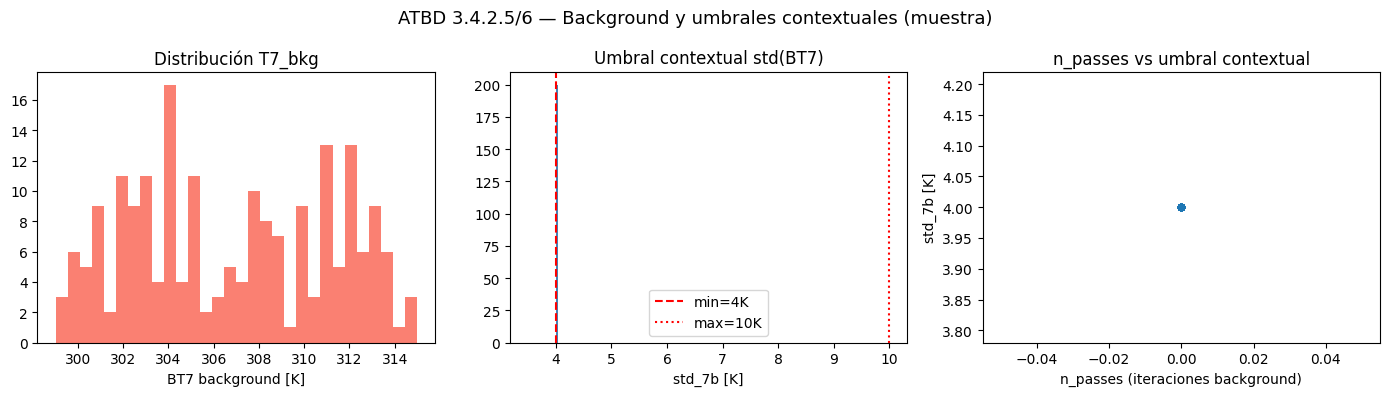

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_bkg['bt7_bkg'], bins=30, color='salmon', edgecolor='none')
axes[0].set_xlabel('BT7 background [K]')
axes[0].set_title('Distribución T7_bkg')

axes[1].hist(df_bkg['std_7b'], bins=30, color='steelblue', edgecolor='none')
axes[1].axvline(4.0, color='red',  linestyle='--', label='min=4K')
axes[1].axvline(10.0, color='red', linestyle=':', label='max=10K')
axes[1].set_xlabel('std_7b [K]')
axes[1].set_title('Umbral contextual std(BT7)')
axes[1].legend()

axes[2].scatter(df_bkg['n_passes'], df_bkg['std_7b'], alpha=0.5, s=20)
axes[2].set_xlabel('n_passes (iteraciones background)')
axes[2].set_ylabel('std_7b [K]')
axes[2].set_title('n_passes vs umbral contextual')

plt.suptitle('ATBD 3.4.2.5/6 — Background y umbrales contextuales (muestra)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 5 — ATBD 3.4.2.8: Correcciones TPW + emisividad + solar

Para un píxel de ejemplo con background válido, mostramos el efecto de cada corrección sobre las temperaturas de brillo.

In [42]:
# Elegir un píxel de la muestra con background válido
row0 = df_bkg.iloc[0]
i0, j0 = int(row0['i']), int(row0['j'])

# Recalcular background para ese píxel
bkg0 = compute_background(
    i0, j0,
    inp.bt7, bt14_eff, refl,
    vis_brightness,
    albedo if inp.refl2 is not None else None,
    inp.land_mask, sza_cos, is_day,
)

# Obtener coeficientes TPW LUT
col = _tpw_lut_indices(float(inp.tpw[i0, j0]), float(inp.lza[i0, j0]))
lut = inp.lut_tpw
trans7, trans14 = float(lut[2, col]), float(lut[3, col])
ext7,   ext14   = float(lut[4, col]), float(lut[5, col])

r7  = float(inp.rad7[i0, j0])
r14 = float(rad14_eff[i0, j0])

# Corrección TPW
r7_corr  = (r7  - ext7  * r7 ) / trans7
r14_corr = (r14 - ext14 * r14) / trans14
T7_corr  = float(planck_temp(7,  r7_corr))
T14_corr = float(planck_temp(14, r14_corr))

# Corrección emisividad
em7  = float(inp.emiss7 [i0, j0])
em14 = float(inp.emiss14[i0, j0])
r7_corr_em  = r7_corr  / em7
r14_corr_em = r14_corr / em14

# Background corregido
r7_bkg_raw   = planck_rad(7,  bkg0.temp7_bkg_mean)
r14_bkg_raw  = planck_rad(14, bkg0.temp14_bkg_mean)
r7_bkg_corr  = (r7_bkg_raw  - ext7  * r7_bkg_raw ) / trans7
r14_bkg_corr = (r14_bkg_raw - ext14 * r14_bkg_raw) / trans14

# Corrección solar
r7_solar_corr, rad7from14_bkg = _solar_correction(
    r7_corr_em, r7_bkg_corr, r14_bkg_corr, em7
)

# Corrección difracción
from fdca.constants import DIFFRAC_CH7_SUB, DIFFRAC_CH7_DIV, DIFFRAC_CH14_SUB, DIFFRAC_CH14_DIV
r7_diff  = (r7_solar_corr - DIFFRAC_CH7_SUB  * rad7from14_bkg) / DIFFRAC_CH7_DIV
r14_diff = (r14_corr      - DIFFRAC_CH14_SUB * r14_bkg_corr)   / DIFFRAC_CH14_DIV

T7c  = float(planck_temp(7,  r7_diff))
T14c = float(planck_temp(14, r14_diff))
Tbc  = float(planck_temp(7,  r7_bkg_corr))

summary = {
    'Paso': ['BT7 original', 'BT7 tras TPW', 'BT7 tras difracción',
              'BT14 original', 'BT14 tras TPW', 'BT14 tras difracción',
              'BT7_bkg (background)', 'BT7c_bkg (corregido)'],
    'Valor [K]': [
        float(inp.bt7[i0, j0]),
        T7_corr, T7c,
        float(bt14_eff[i0, j0]),
        T14_corr, T14c,
        float(bkg0.temp7_bkg_mean), Tbc,
    ]
}
df_corr = pd.DataFrame(summary)
df_corr['Valor [K]'] = df_corr['Valor [K]'].round(3)
print(f'Píxel ejemplo: ({i0}, {j0})  |  SZA={inp.sza[i0,j0]:.1f}°  |  TPW={inp.tpw[i0,j0]:.1f} mm')
print(f'trans7={trans7:.4f}  ext7={ext7:.4f}  em7={em7:.3f}\n')
print(df_corr.to_string(index=False))

Píxel ejemplo: (54, 168)  |  SZA=51.6°  |  TPW=32.6 mm
trans7=0.9480  ext7=0.0047  em7=0.950

                Paso  Valor [K]
        BT7 original    304.770
        BT7 tras TPW    306.000
 BT7 tras difracción    305.936
       BT14 original    301.099
       BT14 tras TPW    306.164
BT14 tras difracción    306.000
BT7_bkg (background)    305.234
BT7c_bkg (corregido)    306.468


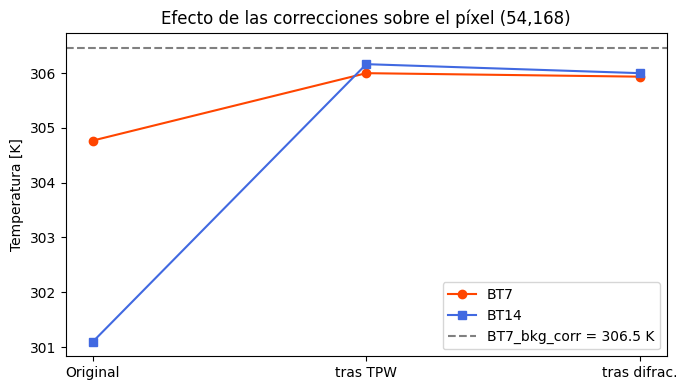

In [43]:
etapas = ['Original', 'tras TPW', 'tras difrac.']
bt7_vals  = [float(inp.bt7[i0,j0]), T7_corr,  T7c]
bt14_vals = [float(bt14_eff[i0,j0]), T14_corr, T14c]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(etapas, bt7_vals,  'o-', color='orangered',   label='BT7')
ax.plot(etapas, bt14_vals, 's-', color='royalblue',   label='BT14')
ax.axhline(Tbc, color='gray', linestyle='--', label=f'BT7_bkg_corr = {Tbc:.1f} K')
ax.set_ylabel('Temperatura [K]')
ax.set_title(f'Efecto de las correcciones sobre el píxel ({i0},{j0})')
ax.legend()
plt.tight_layout()
plt.show()

---
## Paso 6 — ATBD 3.4.2.10: Dozier sub-pixel

Corremos `compute_dozier` para el mismo píxel ejemplo y mostramos la solución `(fire_temp, fire_frac, FRP)`.

In [45]:
doz = compute_dozier(
    r7_diff, r14_diff,
    r7_bkg_corr, r14_bkg_corr,
    Tbc,
    is_potential_glint=False,
)

pix_area = compute_pixel_area(i0, j0, inp.latitudes, inp.longitudes)

print('=== Resultado Dozier ===')
print(f'  valid        : {doz.valid}')
print(f'  fire_temp    : {doz.fire_temp:.2f} K'  if not np.isnan(doz.fire_temp) else '  fire_temp: nan')
print(f'  fire_frac    : {doz.fire_frac:.6f}'    if doz.fire_frac is not None   else '  fire_frac: None')
print(f'  fail_char    : {doz.fail_char}')
print(f'  pixel_area   : {pix_area:.4f} km²')

if doz.valid and doz.fire_frac:
    frp_val = compute_frp(pix_area, r7_diff, r7_bkg_corr)
    fire_area = float(doz.fire_frac) * pix_area
    print(f'  fire_area    : {fire_area:.6f} km²')
    print(f'  FRP          : {frp_val:.4f} MW')

=== Resultado Dozier ===
  valid        : False
  fire_temp    : -999.00 K
  fire_frac    : nan
  fail_char    : 6
  pixel_area   : 4.8661 km²


---
## Paso 7 — Correr `run_part1` completo y analizar resultados

In [46]:
import time

# Obtener LUT y FPT desde el input
lut_tpw = getattr(inp, 'lut_tpw', np.ones((6, 35)))  # fallback si no existe
FPT     = getattr(inp, 'fpt', 0.0) or 0.0

t0 = time.time()
fire_mask_p1, fail_char_p1, candidates = run_part1(
    bt7=inp.bt7, rad7=inp.rad7,
    bt14=inp.bt14, rad14=inp.rad14,
    bt13=inp.bt13, rad13=inp.rad13,
    bt15=inp.bt15,
    refl2=inp.refl2,
    latitudes=inp.latitudes, longitudes=inp.longitudes,
    sza=inp.sza, glint_angle=inp.glint_angle,
    lza=inp.lza, azimuth=inp.azimuth,
    tpw=inp.tpw,
    emiss7=inp.emiss7, emiss14=inp.emiss14,
    lut_tpw=lut_tpw, FPT=FPT,
    land_cover=inp.land_cover, land_mask=inp.land_mask,
    desert_mask=inp.desert_mask, usgs_eco=inp.usgs_eco,
    data_quality=getattr(inp, 'data_quality', None),
)
elapsed = time.time() - t0

print(f'Part I completada en {elapsed:.1f} s')
print(f'Candidatos generados: {len(candidates):,}')

KeyboardInterrupt: 

In [ ]:
# ── Resumen cuantitativo de fail_char ──────────────────────────────────────
vals, counts = np.unique(fail_char_p1[fail_char_p1 != FailChar.NONE], return_counts=True)
fc_names = {v: k for k, v in vars(FailChar).items() if not k.startswith('_') and isinstance(v, int)}

df_fc = pd.DataFrame({
    'fail_char'  : vals,
    'nombre'     : [fc_names.get(v, str(v)) for v in vals],
    'N píxeles'  : counts,
    '% candidatos': (counts / len(candidates) * 100).round(2) if len(candidates) > 0 else 0,
})
print('Distribución de fail_char entre candidatos de Part I:')
print(df_fc.to_string(index=False))

Distribución de fail_char entre candidatos de Part I:
 fail_char nombre  N píxeles  % candidatos
         3     F3          9          0.03
         4     F4      28965        107.26
         5     F5      12588         46.61
         6     F6      14798         54.80
         9     F9       1071          3.97
        10    F10         44          0.16


In [ ]:
# ── Tabla resumen de candidatos ─────────────────────────────────────────────
df_cand = pd.DataFrame([{
    'fire_id'   : c.fire_id,
    'lat'       : round(c.lat, 3),
    'lon'       : round(c.lon, 3),
    'bt7 [K]'   : round(c.bt7, 2),
    'bt14 [K]'  : round(c.bt14, 2),
    'bt7_bkg [K]': round(c.bt7_bkg, 2),
    'fire_temp [K]': round(c.fire_temp, 1) if not np.isnan(c.fire_temp) else np.nan,
    'fire_frac' : round(c.fire_frac, 6),
    'frp [MW]'  : round(c.frp, 3),
    'fail_char' : c.fail_char,
    'is_day'    : c.is_day,
} for c in candidates])

print(f'Primeros 20 candidatos (de {len(df_cand):,} total):')
print(df_cand.head(20).to_string(index=False))

Primeros 20 candidatos (de 27,005 total):
 fire_id   lat     lon  bt7 [K]  bt14 [K]  bt7_bkg [K]  fire_temp [K]  fire_frac  frp [MW]  fail_char  is_day
       1 -29.5 -58.560   313.97    307.84       313.29         -999.0        0.0     1.764          4    True
       2 -29.5 -58.536   313.55    307.70       313.22         -999.0        0.0     0.466          4    True
       3 -29.5 -58.467   313.13    307.32       312.97         -999.0        0.0    -0.281          4    True
       4 -29.5 -58.444   313.42    307.37       312.90         -999.0        0.0     0.902          4    True
       5 -29.5 -58.421   313.50    307.51       312.83         -999.0        0.0     1.380          4    True
       6 -29.5 -58.351   312.89    306.91       312.71         -999.0        0.0    -0.606          4    True
       7 -29.5 -58.328   313.37    307.16       312.69         -999.0        0.0     1.012          4    True
       8 -29.5 -58.258   312.56    306.66       312.42         -999.0        0

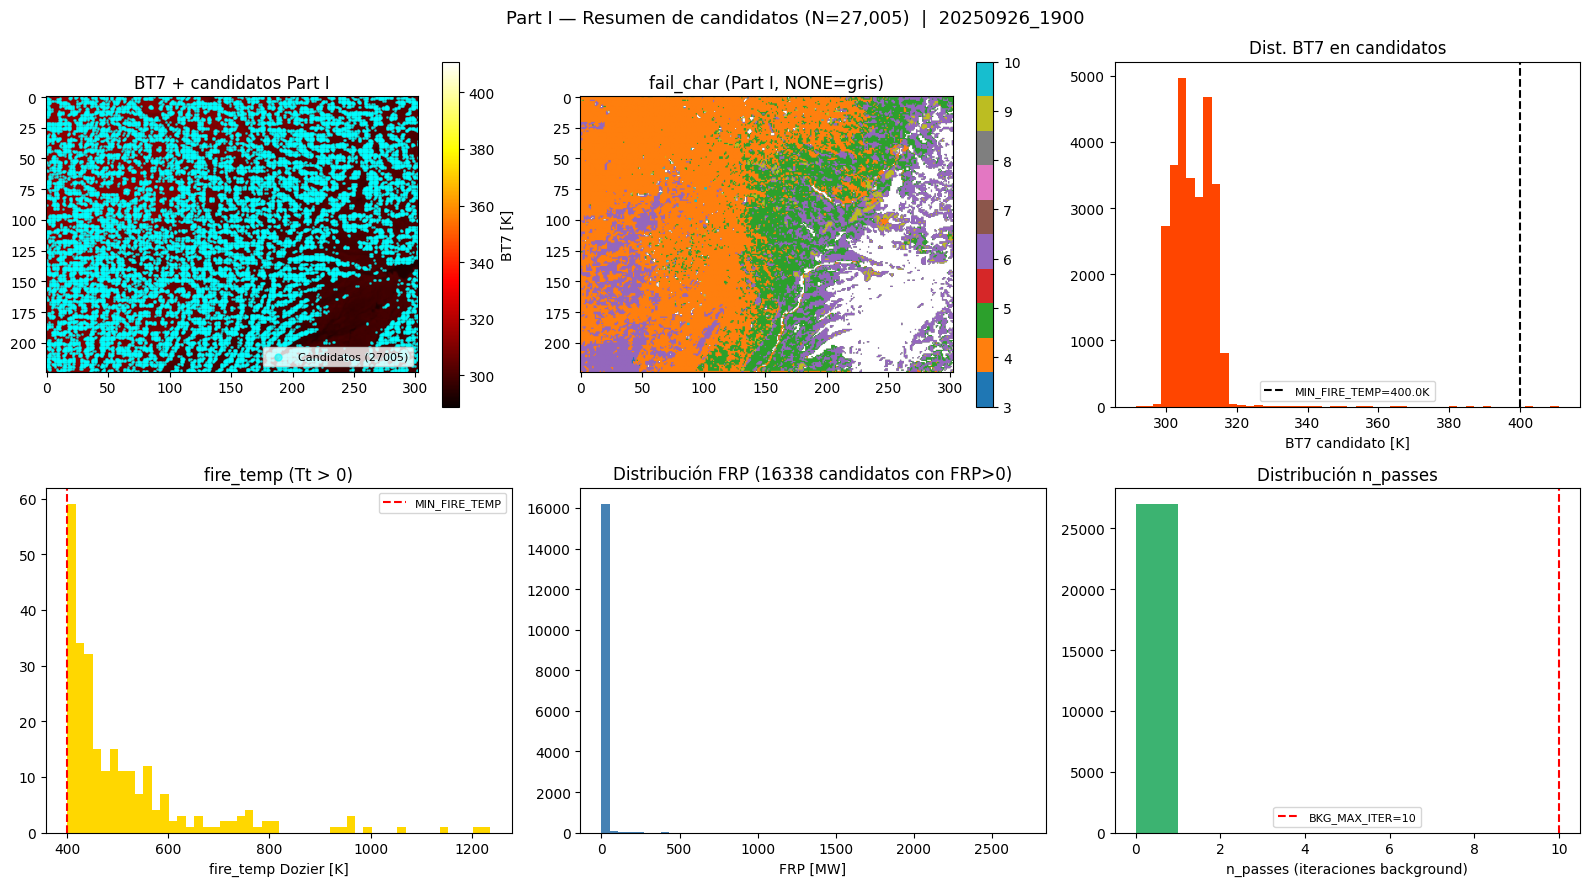

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1) BT7 con candidatos marcados
ax = axes[0, 0]
im = ax.imshow(inp.bt7, cmap='hot', origin='upper')
plt.colorbar(im, ax=ax, label='BT7 [K]')
if candidates:
    ci = [c.i for c in candidates]
    cj = [c.j for c in candidates]
    ax.scatter(cj, ci, s=1, c='cyan', alpha=0.6, label=f'Candidatos ({len(candidates)})')
ax.set_title('BT7 + candidatos Part I')
ax.legend(markerscale=5, fontsize=8)

# 2) fail_char map
ax = axes[0, 1]
fc_display = np.where(fail_char_p1 == FailChar.NONE, np.nan, fail_char_p1.astype(float))
im = ax.imshow(fc_display, cmap='tab10', origin='upper')
plt.colorbar(im, ax=ax)
ax.set_title('fail_char (Part I, NONE=gris)')

# 3) Distribución BT7 candidatos
ax = axes[0, 2]
if candidates:
    ax.hist([c.bt7 for c in candidates], bins=50, color='orangered', edgecolor='none')
    ax.axvline(MIN_FIRE_TEMP, color='k', linestyle='--', label=f'MIN_FIRE_TEMP={MIN_FIRE_TEMP}K')
ax.set_xlabel('BT7 candidato [K]')
ax.set_title('Dist. BT7 en candidatos')
ax.legend(fontsize=8)

# 4) fire_temp de Dozier (sólo válidos)
ax = axes[1, 0]
fire_temps = [c.fire_temp for c in candidates if c.fire_temp and c.fire_temp > 0]
if fire_temps:
    ax.hist(fire_temps, bins=50, color='gold', edgecolor='none')
    ax.axvline(MIN_FIRE_TEMP, color='r', linestyle='--', label=f'MIN_FIRE_TEMP')
ax.set_xlabel('fire_temp Dozier [K]')
ax.set_title('fire_temp (Tt > 0)')
ax.legend(fontsize=8)

# 5) FRP
ax = axes[1, 1]
frps = [c.frp for c in candidates if c.frp and c.frp > 0]
if frps:
    ax.hist(frps, bins=50, color='steelblue', edgecolor='none')
ax.set_xlabel('FRP [MW]')
ax.set_title(f'Distribución FRP ({len(frps)} candidatos con FRP>0)')

# 6) n_passes
ax = axes[1, 2]
npasses = [c.n_passes for c in candidates]
if npasses:
    ax.hist(npasses, bins=range(0, max(npasses)+2), color='mediumseagreen', edgecolor='none')
    ax.axvline(BKG_MAX_ITER, color='r', linestyle='--', label=f'BKG_MAX_ITER={BKG_MAX_ITER}')
ax.set_xlabel('n_passes (iteraciones background)')
ax.set_title('Distribución n_passes')
ax.legend(fontsize=8)

plt.suptitle(f'Part I — Resumen de candidatos (N={len(candidates):,})  |  {TIMESTAMP}', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 8 — Mapa geográfico de candidatos

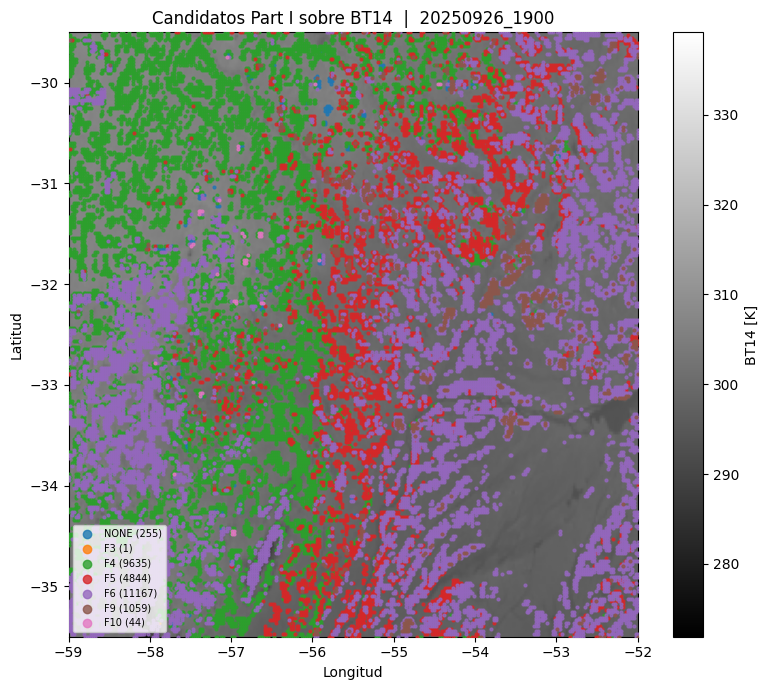

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

# BT14 como fondo
im = ax.imshow(
    bt14_eff,
    cmap='gray', origin='upper',
    extent=[inp.longitudes.min(), inp.longitudes.max(),
            inp.latitudes.min(),  inp.latitudes.max()],
    aspect='auto',
)
plt.colorbar(im, ax=ax, label='BT14 [K]')

# Candidatos por fail_char
fc_groups = {}
for c in candidates:
    fc = c.fail_char
    fc_groups.setdefault(fc, []).append((c.lon, c.lat))

colors_fc = plt.cm.tab10.colors
for idx, (fc, pts) in enumerate(sorted(fc_groups.items())):
    lons, lats = zip(*pts)
    label = fc_names.get(fc, str(fc))
    ax.scatter(lons, lats, s=4, color=colors_fc[idx % 10],
               alpha=0.8, label=f'{label} ({len(pts)})', zorder=5)

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title(f'Candidatos Part I sobre BT14  |  {TIMESTAMP}')
ax.legend(fontsize=7, markerscale=3, loc='lower left')
plt.tight_layout()
plt.show()

---
## Paso 9 — Análisis de valores únicos en `fire_mask_p1` (diagnóstico §9.3)

In [ ]:
vals, counts = np.unique(fire_mask_p1, return_counts=True)
fm_names = {v: k for k, v in vars(FireMask).items() if not k.startswith('_') and isinstance(v, int)}

df_fm = pd.DataFrame({
    'fire_mask_val': vals,
    'nombre'       : [fm_names.get(v, str(v)) for v in vals],
    'N píxeles'    : counts,
    '% total'      : (counts / (L * W) * 100).round(3),
})
print('Distribución de valores en fire_mask_p1:')
print(df_fm.to_string(index=False))

# Verificación: ¿hay valores en rango 30-35 (temporales) en Part I? (no debería)
temporal_in_p1 = int(np.isin(fire_mask_p1, [30,31,32,33,34,35]).sum())
print(f'\nPíxeles 30-35 en fire_mask_p1 (debería ser 0): {temporal_in_p1}')

Distribución de valores en fire_mask_p1:
 fire_mask_val    nombre  N píxeles  % total
           -99      INIT      57730   85.057
           100 FIRE_FREE      10142   14.943

Píxeles 30-35 en fire_mask_p1 (debería ser 0): 0


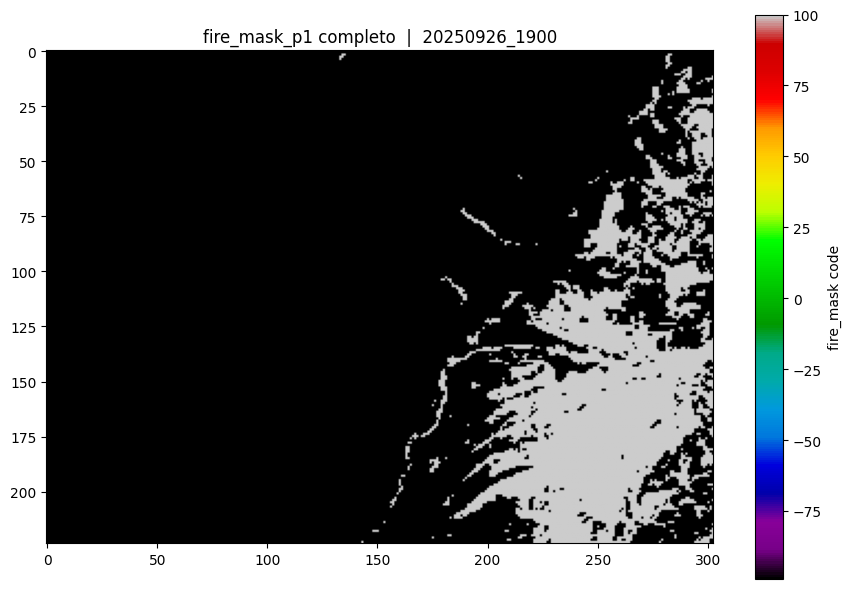


Nota: los píxeles candidatos (que pasan a Part II) tienen fire_mask == FireMask.INIT
  FireMask.INIT = -99


In [ ]:
# Visualización de la fire_mask de Part I
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(fire_mask_p1, cmap='nipy_spectral', origin='upper',
               vmin=fire_mask_p1.min(), vmax=fire_mask_p1.max())
plt.colorbar(im, ax=ax, label='fire_mask code')
ax.set_title(f'fire_mask_p1 completo  |  {TIMESTAMP}')
plt.tight_layout()
plt.show()

print('\nNota: los píxeles candidatos (que pasan a Part II) tienen fire_mask == FireMask.INIT')
print(f'  FireMask.INIT = {FireMask.INIT}')

---
## ¿Qué sigue?

La lista `candidates` y los arrays `fire_mask_p1`, `fail_char_p1` son la entrada de **Part II** (`run_part2`), que aplica:
- tests de confirmación / eliminación de falsas alarmas (`cond1`, `cond2`, `cond3`)
- upgrade de confianza (→ HIGH/MED/LOW)
- filtrado temporal (offset +20)

El notebook de Part II seguirá la misma estructura modular.